In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

## Hopfield memory network - Hebbian construction rule

In [4]:
N = 100
P = 50

memory = np.random.choice([-1, 1], size=(P, N))

print(memory.shape)

(50, 100)


In [47]:
# Matrix 

M = np.zeros((N, N))

for m in memory:
    M += np.outer(m, m)
np.fill_diagonal(M, 0)

In [5]:
def overlap(state, memory):
    return np.dot(state, memory) / N

state = memory[0].copy()  # Start with the first memory pattern
noise = np.random.choice(N, 20, replace=False)  # Add some noise by flipping 20 random bits
state[noise] *= -1  # Flip the bits to create a noisy state

print("Initial overlap with memory patterns:", overlap(state,memory[0]))

Initial overlap with memory patterns: 0.6


In [49]:
print(memory[0][:40])
print(state[:40])

print(memory[0][:40] - state[:40])

[ 1  1  1  1 -1 -1  1 -1  1 -1  1 -1  1  1 -1 -1 -1  1  1  1 -1  1  1 -1
  1 -1 -1  1 -1  1  1  1 -1  1 -1 -1  1  1  1 -1]
[ 1  1  1  1 -1 -1  1 -1  1 -1  1 -1  1  1 -1 -1 -1  1  1  1 -1  1  1 -1
  1 -1 -1  1 -1  1  1  1 -1  1 -1 -1  1  1  1 -1]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0]


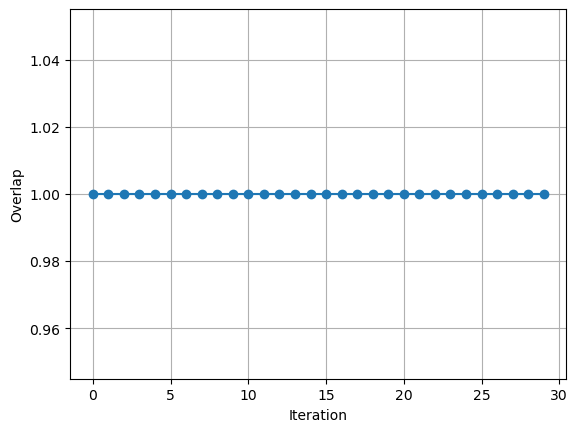

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [7]:
def update_rule(state, M):
    input = M @ state
    new_state = np.sign(input)
    new_state[new_state == 0] = 1  # Handle zero case
    return new_state

steps = 30
q_vals = []

for i in range(steps):
    state = update_rule(state, M)
    q_vals.append(overlap(state, memory[0]))

plt.plot(q_vals, marker='o')

plt.xlabel("Iteration")
plt.ylabel("Overlap")

plt.grid(True)
plt.show()

print(memory[0][:40] - state[:40])

In [60]:
for p in P_vals:
    print(N_vals[p-1])

50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149


In [59]:
N_vals.shape
P_vals.shape

(100,)

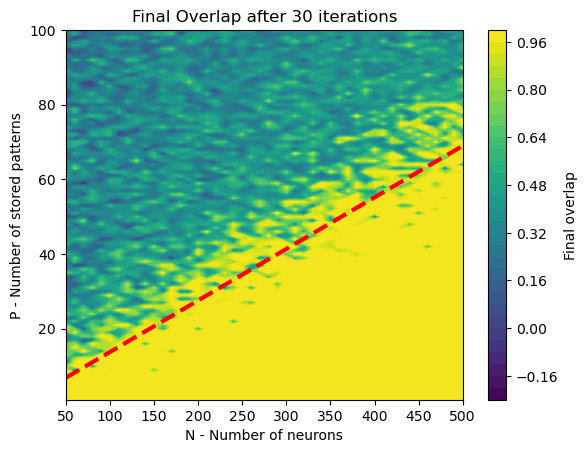

In [ ]:
P_vals = np.arange(1, 101)
N_vals = np.arange(50, 501, 10)

final_overlap = np.zeros((len(P_vals), len(N_vals)))

for i, P in enumerate(P_vals):
    for j, N in enumerate(N_vals):

        memory = np.random.choice([-1, 1], size=(P, N))

        M = np.zeros((N, N))
        for m in memory:
            M += np.outer(m, m)

        np.fill_diagonal(M, 0)

        state = memory[0].copy()
        fraction_noise = 0.2

        noise = np.random.choice(N, int(fraction_noise * N), replace=False)
        state[noise] *= -1

        for _ in range(30):
            state = update_rule(state, M)

        final_overlap[i, j] = overlap(state, memory[0])

N_grid, P_grid = np.meshgrid(N_vals, P_vals)
alpha_c = 0.138

N_line = np.linspace(N_vals.min(), N_vals.max(), 500)
P_line = alpha_c * N_line
plt.contourf(
    N_grid,
    P_grid,
    final_overlap,
    levels=30,
    cmap="viridis"
)

plt.plot(
    N_line,
    P_line,
    'r--',
    linewidth=3,
    label=r'$P/N=0.138$'
)

plt.xlabel("N - Number of neurons")
plt.ylabel("P - Number of stored patterns")
plt.title("Final Overlap after 30 iterations")
plt.colorbar(label="Final overlap")
plt.show()

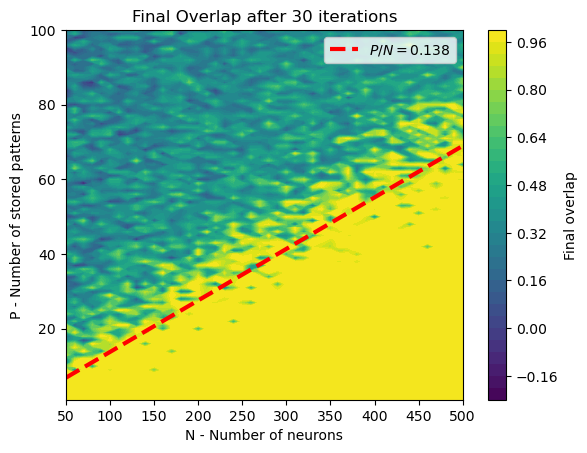

In [10]:
N_grid, P_grid = np.meshgrid(N_vals, P_vals)
alpha_c = 0.138

N_line = np.linspace(N_vals.min(), N_vals.max(), 500)
P_line = alpha_c * N_line
plt.contourf(
    N_grid,
    P_grid,
    final_overlap,
    levels=30,
    cmap="viridis"
)

plt.plot(
    N_line,
    P_line,
    'r--',
    linewidth=3,
    label=r'$P/N=0.138$'
)

plt.xlabel("N - Number of neurons")
plt.ylabel("P - Number of stored patterns")
plt.title("Final Overlap after 30 iterations")
plt.legend()
plt.colorbar(label="Final overlap")
plt.show()

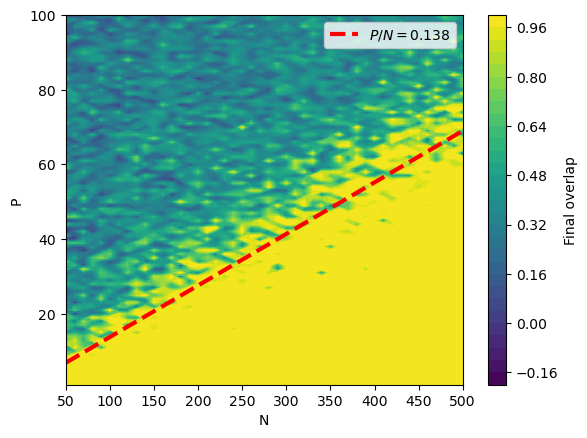

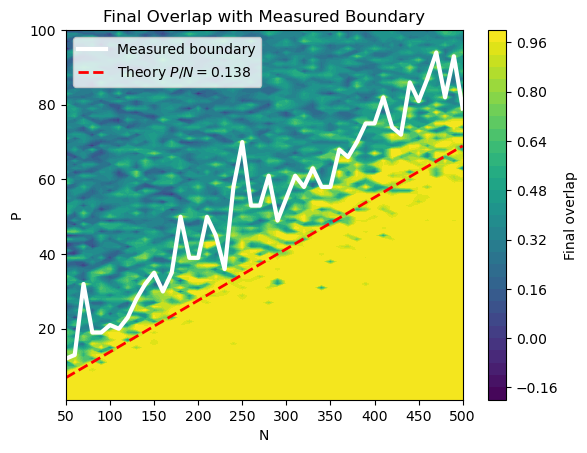

In [68]:
alpha_c = 0.138

N_line = np.linspace(N_vals.min(), N_vals.max(), 500)
P_line = alpha_c * N_line

plt.contourf(
    N_grid,
    P_grid,
    final_overlap,
    levels=30,
    cmap="viridis"
)

plt.plot(
    N_line,
    P_line,
    'r--',
    linewidth=3,
    label=r'$P/N=0.138$'
)

plt.legend()
plt.xlabel("N")
plt.ylabel("P")
plt.colorbar(label="Final overlap")
plt.show()

boundary_P = []

for j in range(len(N_vals)):

    idx = np.where(final_overlap[:, j] > 0.8)[0]

    if len(idx) > 0:
        boundary_P.append(P_vals[idx[-1]])
    else:
        boundary_P.append(np.nan)

plt.contourf(
    N_grid,
    P_grid,
    final_overlap,
    levels=30,
    cmap='viridis'
)

plt.plot(
    N_vals,
    boundary_P,
    'w-',
    linewidth=3,
    label='Measured boundary'
)

plt.plot(
    N_line,
    0.138*N_line,
    'r--',
    linewidth=2,
    label='Theory $P/N=0.138$'
)

plt.xlabel("N")
plt.ylabel("P")
plt.title("Final Overlap with Measured Boundary")
plt.colorbar(label="Final overlap")
plt.legend()
plt.show()

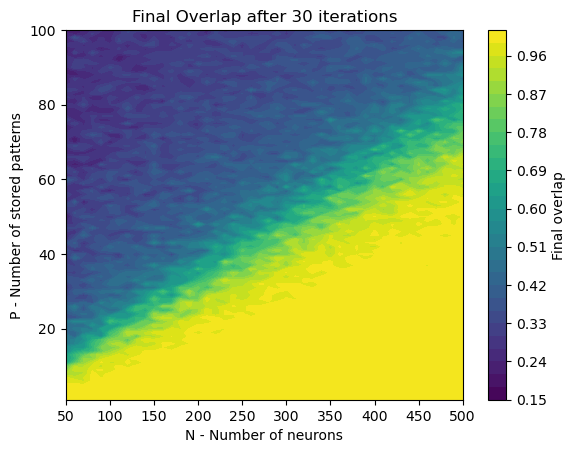

In [69]:
n_trials = 20
for i, P in enumerate(P_vals):

    for j, N in enumerate(N_vals):

        overlaps = []

        for trial in range(n_trials):

            memories = np.random.choice(
                [-1,1],
                size=(P,N)
            )

            M = np.zeros((N,N))

            for m in memories:
                M += np.outer(m,m)

            np.fill_diagonal(M,0)

            state = memories[0].copy()

            num_flip = int(0.2*N)

            noise = np.random.choice(
                N,
                num_flip,
                replace=False
            )

            state[noise] *= -1

            for _ in range(30):
                state = update_rule(state,M)

            overlaps.append(
                overlap(state,memories[0])
            )

        final_overlap[i,j] = np.mean(overlaps)

N_grid, P_grid = np.meshgrid(N_vals, P_vals)

plt.contourf(
    N_grid,
    P_grid,
    final_overlap,
    levels=30,
    cmap="viridis"
)

plt.xlabel("N - Number of neurons")
plt.ylabel("P - Number of stored patterns")
plt.title("Final Overlap after 30 iterations")
plt.colorbar(label="Final overlap")
plt.show()

# Alpha experiment - P/N

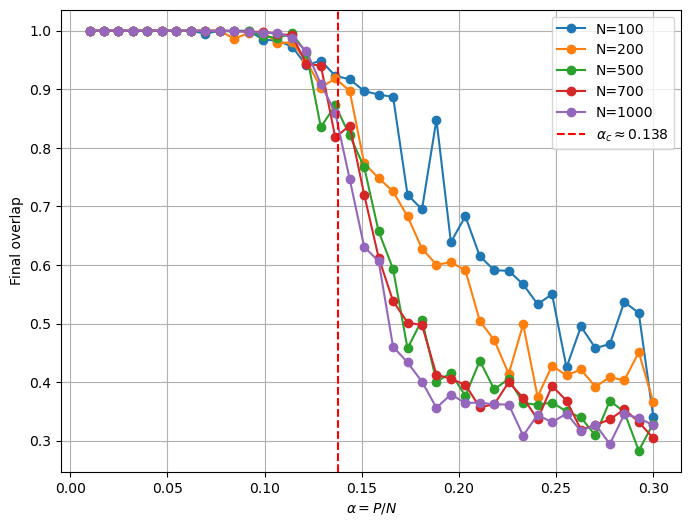

In [70]:
alphas = np.linspace(0.01,0.30,40)
N_values = [100,200,500, 700, 1000]

overlap_vs_alpha = {}

n_trials = 20

for N in N_values:

    mean_overlap = []

    for alpha in alphas:

        P = max(1,int(alpha*N))

        overlaps = []

        for trial in range(n_trials):

            memories = np.random.choice(
                [-1,1],
                size=(P,N)
            )

            M = np.zeros((N,N))

            for m in memories:
                M += np.outer(m,m)

            np.fill_diagonal(M,0)

            state = memories[0].copy()

            num_flip = int(0.2*N)

            noise = np.random.choice(
                N,
                num_flip,
                replace=False
            )

            state[noise] *= -1

            for _ in range(30):
                state = update_rule(state,M)

            overlaps.append(
                overlap(state, memories[0])
            )

        mean_overlap.append(
            np.mean(overlaps)
        )

    overlap_vs_alpha[N] = np.array(mean_overlap)


plt.figure(figsize=(8,6))

for N in N_values:

    plt.plot(
        alphas,
        overlap_vs_alpha[N],
        marker='o',
        label=f'N={N}'
    )

plt.axvline(
    0.138,
    color='red',
    linestyle='--',
    label=r'$\alpha_c \approx 0.138$'
)

plt.xlabel(r'$\alpha=P/N$')
plt.ylabel('Final overlap')

plt.legend()

plt.grid()

plt.show()

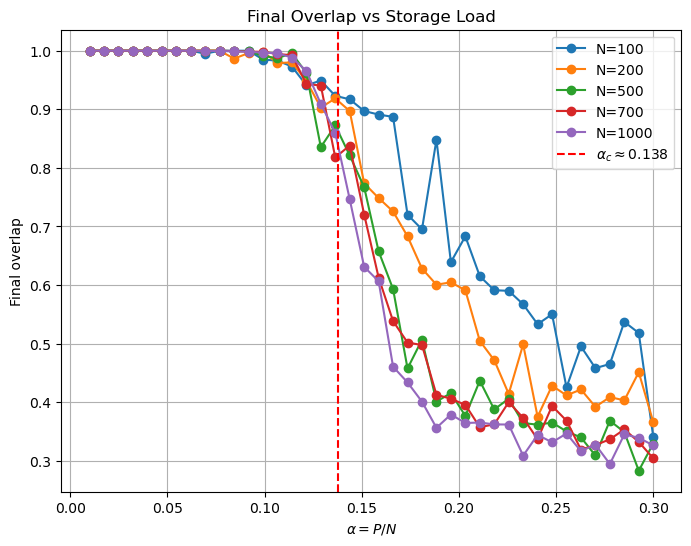

In [71]:
plt.figure(figsize=(8,6))

for N in N_values:

    plt.plot(
        alphas,
        overlap_vs_alpha[N],
        marker='o',
        label=f'N={N}'
    )

plt.axvline(
    0.138,
    color='red',
    linestyle='--',
    label=r'$\alpha_c \approx 0.138$'
)

plt.xlabel(r'$\alpha=P/N$')
plt.ylabel('Final overlap')
plt.title("Final Overlap vs Storage Load")
plt.legend()

plt.grid()

plt.show()

Basin of attraction - corrupt memory

In [21]:
flip_fraction = np.linspace(0, 0.5, 10)
N = 500 

alphas =  np.linspace(0.01, 0.30, 40)
n_trials = 10
mean_final_overlap = {}

def update_rule(state, M):
    input = M @ state
    new_state = np.sign(input)
    new_state[new_state == 0] = 1  # Handle zero case
    return new_state

def overlap(state, memory):
    return np.dot(state, memory) / N

for alpha in alphas:
    P = int(alpha * N)

    for f in flip_fraction:
        overlaps = []

        for trial in range(n_trials):

            memory = np.random.choice(
                [-1,1],
                size=(P,N)
            )

            M = np.zeros((N,N))

            for m in memory:
                M += np.outer(m,m)

            np.fill_diagonal(M,0)

            state = memory[0].copy()

            num_flip = int(f * N)

            noise = np.random.choice(
                N,
                num_flip,
                replace=False
            )

            state[noise] *= -1

            for _ in range(30):
                state = update_rule(state,M)

            overlaps.append(
                overlap(state, memory[0])
            )

        mean_final_overlap[(alpha, f)] = np.mean(overlaps)






In [17]:
np.arange(0.01, 0.31, 0.05)

array([0.01, 0.06, 0.11, 0.16, 0.21, 0.26])

"""for alpha in alphas:
    P = int(alpha * N)
    overlaps = []
    for trial in range(n_trials):
        memory = np.random.choice([-1, 1], size=(P, N))
        M = np.zeros((N, N))
        for m in memory:
            M += np.outer(m, m)
        np.fill_diagonal(M, 0)
        state = memory[0].copy()
        for f in flip_fraction:
            num_flip = int(f * N)
            noise = np.random.choice(N, num_flip, replace=False)
            state[noise] *= -1
            for _ in range(30):
                state = update_rule(state, M)
            overlaps.append(overlap(state, memory[0]))

    mean_final_overlap.append(np.mean(overlaps))"""

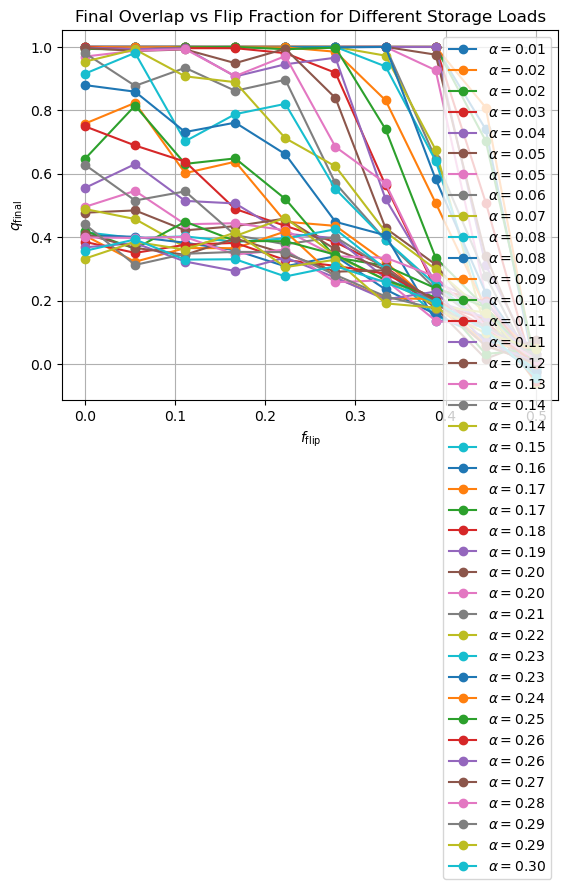

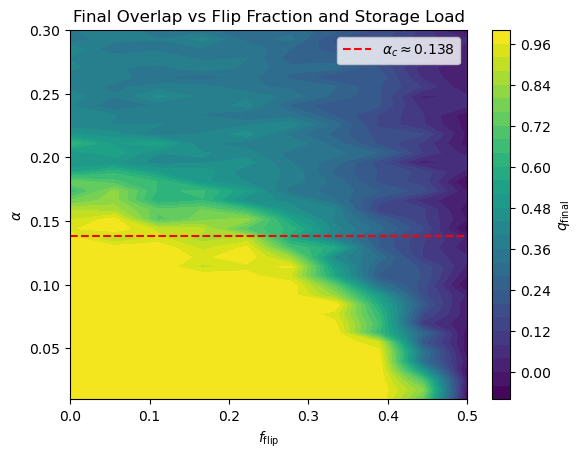

In [28]:
for alpha in alphas:

    q_vals = [
        mean_final_overlap[(alpha, f)]
        for f in flip_fraction
    ]

    plt.plot(
        flip_fraction,
        q_vals,
        marker='o',
        label=fr'$\alpha={alpha:.2f}$'
    )

plt.title("Final Overlap vs Flip Fraction for Different Storage Loads")
plt.xlabel(r'$f_{\rm flip}$')
plt.ylabel(r'$q_{\rm final}$')
plt.legend()
plt.grid()
plt.show()

Q = np.zeros((len(alphas), len(flip_fraction)))

for i, alpha in enumerate(alphas):
    for j, f in enumerate(flip_fraction):
        Q[i,j] = mean_final_overlap[(alpha,f)]

plt.contourf(
    flip_fraction,
    alphas,
    Q,
    levels=30
)

plt.colorbar(label=r'$q_{\rm final}$')
plt.title("Final Overlap vs Flip Fraction and Storage Load")
plt.axhline(0.138, color='red', linestyle='--', label=r'$\alpha_c \approx 0.138$')
plt.xlabel(r'$f_{\rm flip}$')
plt.ylabel(r'$\alpha$')
plt.legend()
plt.show()

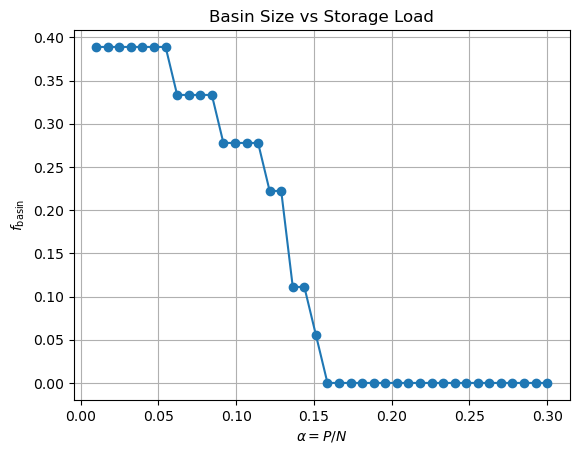

In [26]:
basin_sizes = []

threshold = 0.9

for alpha in alphas:

    valid_f = []

    for f in flip_fraction:

        if mean_final_overlap[(alpha, f)] > threshold:
            valid_f.append(f)

    if len(valid_f) > 0:
        basin_sizes.append(max(valid_f))
    else:
        basin_sizes.append(0)

plt.plot(alphas, basin_sizes, marker='o')

plt.xlabel(r'$\alpha=P/N$')
plt.ylabel(r'$f_{\rm basin}$')
plt.title('Basin Size vs Storage Load')

plt.grid()
plt.show()

# Inverse correlated weight matrix 

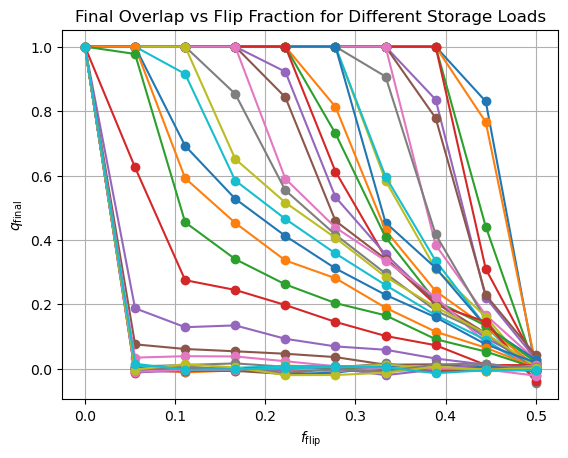

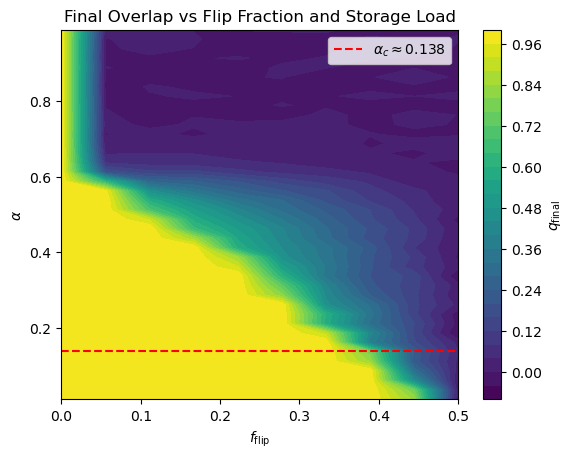

In [31]:
flip_fraction = np.linspace(0, 0.5, 10)
N = 500 

alphas =  np.linspace(0.01, 0.99, 40)
n_trials = 10
mean_final_overlap = {}

def update_rule(state, M):
    input = M @ state
    new_state = np.sign(input)
    new_state[new_state == 0] = 1  # Handle zero case
    return new_state

def overlap(state, memory):
    return np.dot(state, memory) / N

for alpha in alphas:
    P = int(alpha * N)

    for f in flip_fraction:
        overlaps = []

        for trial in range(n_trials):

            memory = np.random.choice(
                [-1,1],
                size=(P,N)
            )

            M = np.zeros((N,N))

            C_inv = memory @ memory.T

            C = np.linalg.inv(C_inv)

            M = memory.T @ C @ memory

            np.fill_diagonal(M,0)

            state = memory[0].copy()

            num_flip = int(f * N)

            noise = np.random.choice(
                N,
                num_flip,
                replace=False
            )

            state[noise] *= -1

            for _ in range(30):
                state = update_rule(state,M)

            overlaps.append(
                overlap(state, memory[0])
            )

        mean_final_overlap[(alpha, f)] = np.mean(overlaps)




for alpha in alphas:

    q_vals = [
        mean_final_overlap[(alpha, f)]
        for f in flip_fraction
    ]

    plt.plot(
        flip_fraction,
        q_vals,
        marker='o',
        label=fr'$\alpha={alpha:.2f}$'
    )

plt.title("Final Overlap vs Flip Fraction for Different Storage Loads")
plt.xlabel(r'$f_{\rm flip}$')
plt.ylabel(r'$q_{\rm final}$')
#plt.legend()
plt.grid()
plt.show()

Q = np.zeros((len(alphas), len(flip_fraction)))

for i, alpha in enumerate(alphas):
    for j, f in enumerate(flip_fraction):
        Q[i,j] = mean_final_overlap[(alpha,f)]

plt.contourf(
    flip_fraction,
    alphas,
    Q,
    levels=30
)

plt.colorbar(label=r'$q_{\rm final}$')
plt.title("Final Overlap vs Flip Fraction and Storage Load")
plt.axhline(0.138, color='red', linestyle='--', label=r'$\alpha_c \approx 0.138$')
plt.xlabel(r'$f_{\rm flip}$')
plt.ylabel(r'$\alpha$')
plt.legend()
plt.show()

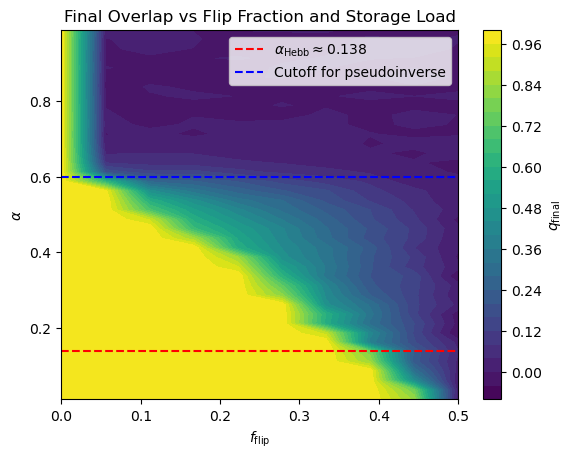

In [32]:
Q = np.zeros((len(alphas), len(flip_fraction)))

for i, alpha in enumerate(alphas):
    for j, f in enumerate(flip_fraction):
        Q[i,j] = mean_final_overlap[(alpha,f)]

plt.contourf(
    flip_fraction,
    alphas,
    Q,
    levels=30
)

plt.colorbar(label=r'$q_{\rm final}$')
plt.title("Final Overlap vs Flip Fraction and Storage Load")
plt.axhline(0.138, color='red', linestyle='--', label=r'$\alpha_{\rm Hebb} \approx 0.138$')
plt.axhline(0.6, color='blue', linestyle='--', label='Cutoff for pseudoinverse')
plt.xlabel(r'$f_{\rm flip}$')
plt.ylabel(r'$\alpha$')
plt.legend()
plt.show()

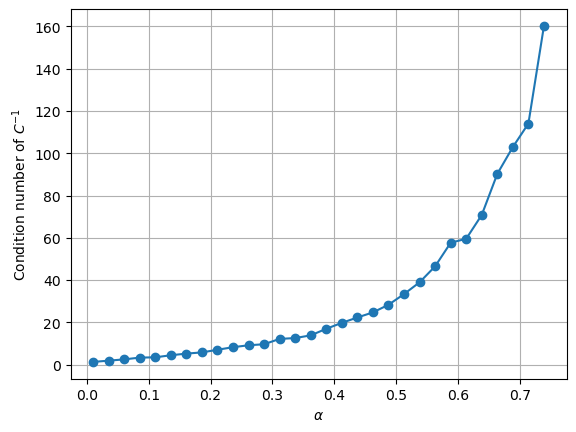

In [37]:
C_cond = []
for alpha in alphas[:30]:
    memory = np.random.choice([-1, 1], size=(int(alpha*N), N))
    C_inv = memory @ memory.T
    C_cond.append(np.linalg.cond(C_inv))

plt.plot(alphas[:30], C_cond, marker = 'o')
plt.xlabel(r'$\alpha$')
plt.ylabel('Condition number of $C^{-1}$')
plt.grid(True)

In [41]:
alphas

array([0.01      , 0.03512821, 0.06025641, 0.08538462, 0.11051282,
       0.13564103, 0.16076923, 0.18589744, 0.21102564, 0.23615385,
       0.26128205, 0.28641026, 0.31153846, 0.33666667, 0.36179487,
       0.38692308, 0.41205128, 0.43717949, 0.46230769, 0.4874359 ,
       0.5125641 , 0.53769231, 0.56282051, 0.58794872, 0.61307692,
       0.63820513, 0.66333333, 0.68846154, 0.71358974, 0.73871795,
       0.76384615, 0.78897436, 0.81410256, 0.83923077, 0.86435897,
       0.88948718, 0.91461538, 0.93974359, 0.96487179, 0.99      ])

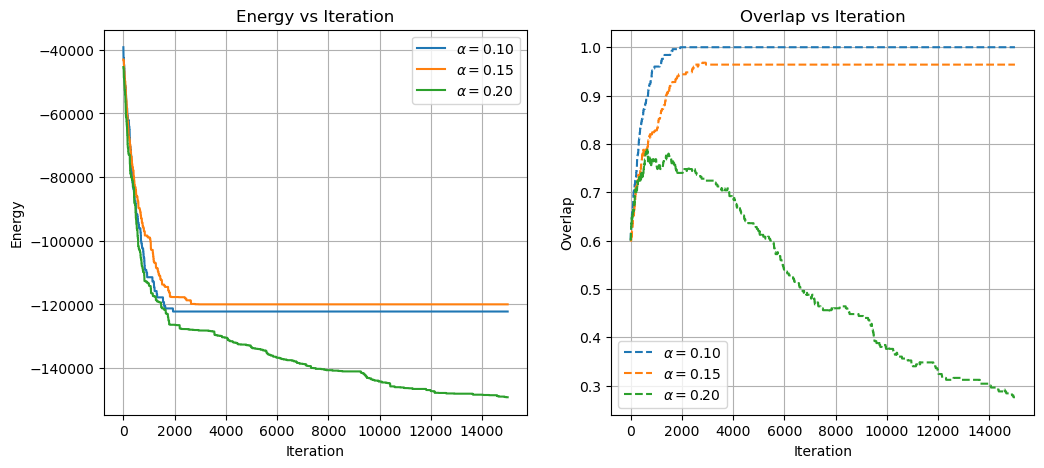

In [55]:
def energy(state, M):
    return -0.5 * state @ M @ state

def update_rule_async(state, M):
    N = len(state)
    i = np.random.randint(N)

    input = M[i]@state
    state[i] = 1 if input >= 0 else -1

    return state

alphas = [0.1, 0.15, 0.2]

plt.figure(figsize=(12,5))
for alpha in alphas:

    P = int(alpha * N)
    memory = np.random.choice([-1, 1], size=(P, N))
    M = np.zeros((N, N))
    for m in memory:
        M += np.outer(m, m)
    np.fill_diagonal(M, 0)

    state = memory[0].copy()
    num_flip = int(0.2 * N)
    noise = np.random.choice(N, num_flip, replace=False)
    state[noise] *=-1
    energies = []
    overlaps = []

    for _ in range(30 * N):
        energies.append(energy(state, M))
        overlaps.append(overlap(state, memory[0]))
        state = update_rule_async(state, M)
    
    plt.subplot(1,2,1)
    plt.plot(energies, label=fr'$\alpha={alpha:.2f}$')
    plt.xlabel("Iteration")
    plt.ylabel("Energy")
    plt.title("Energy vs Iteration")
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(overlaps, label=fr'$\alpha={alpha:.2f}$', linestyle='--')
    plt.xlabel("Iteration")
    plt.ylabel("Overlap")
    plt.title("Overlap vs Iteration")
    plt.legend()
    plt.grid(True)


plt.show()



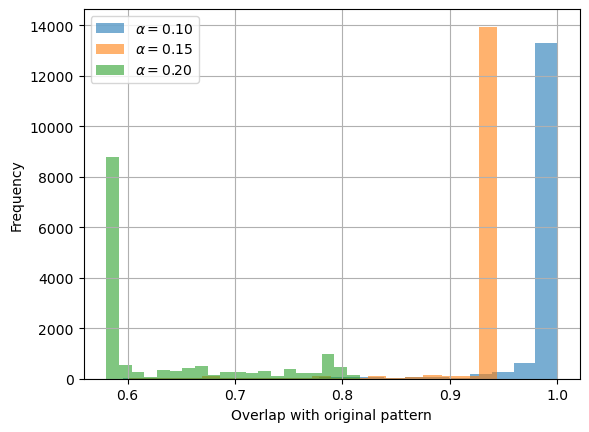

In [59]:
def energy(state, M):
    return -0.5 * state @ M @ state

def update_rule_async(state, M):
    N = len(state)
    i = np.random.randint(N)

    input = M[i]@state
    state[i] = 1 if input >= 0 else -1

    return state

alphas = [0.1, 0.15, 0.2]

for alpha in alphas:

    P = int(alpha * N)
    memory = np.random.choice([-1, 1], size=(P, N))
    M = np.zeros((N, N))
    for m in memory:
        M += np.outer(m, m)
    np.fill_diagonal(M, 0)

    state = memory[0].copy()
    num_flip = int(0.2 * N)
    noise = np.random.choice(N, num_flip, replace=False)
    state[noise] *=-1
    energies = []
    overlaps = []

    for _ in range(30 * N):
        energies.append(energy(state, M))
        overlaps.append(overlap(state, memory[0]))
        state = update_rule_async(state, M)
    
    plt.hist(overlaps, bins = 20, label=fr'$\alpha={alpha:.2f}$', alpha=0.6)


plt.xlabel("Overlap with original pattern")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()



# Spurious attractors